#***LIBRERIAS***

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

#***DATASET Y PROCESAMIENTO***

In [2]:
aire = pd.read_csv("../data/AirQuality.csv", sep=";", encoding="latin1")
aire.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [3]:
aire = aire.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
aire.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


In [4]:
columnas_a_convertir = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']

for col in columnas_a_convertir:
    aire[col] = aire[col].str.replace(',', '.').astype(float)

In [5]:
aire_limpio = aire.dropna()
(aire_limpio == -200).sum()
aire_limpio = aire_limpio.drop(columns=['NMHC(GT)'])
aire_limpio = aire_limpio.replace(-200, np.nan)
aire_limpio = aire_limpio.dropna()
aire_limpio.shape

(6941, 14)

In [6]:
aire_limpio['Datetime'] = pd.to_datetime(aire_limpio['Date'] + ' ' + aire_limpio['Time'], format='%d/%m/%Y %H.%M.%S')

aire_limpio['HOUR'] = aire_limpio['Datetime'].dt.hour + aire_limpio['Datetime'].dt.minute / 60 + aire_limpio['Datetime'].dt.second / 3600

aire_limpio['MOUNT'] = aire_limpio['Datetime'].dt.month
aire_limpio['DayOfWeek'] = aire_limpio['Datetime'].dt.dayofweek

aire_limpio = aire_limpio.drop(columns = ['Date','Time'])

In [7]:
aire_limpio.head()
aire_limpio.info()
aire_limpio.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6941 entries, 0 to 9356
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         6941 non-null   float64       
 1   PT08.S1(CO)    6941 non-null   float64       
 2   C6H6(GT)       6941 non-null   float64       
 3   PT08.S2(NMHC)  6941 non-null   float64       
 4   NOx(GT)        6941 non-null   float64       
 5   PT08.S3(NOx)   6941 non-null   float64       
 6   NO2(GT)        6941 non-null   float64       
 7   PT08.S4(NO2)   6941 non-null   float64       
 8   PT08.S5(O3)    6941 non-null   float64       
 9   T              6941 non-null   float64       
 10  RH             6941 non-null   float64       
 11  AH             6941 non-null   float64       
 12  Datetime       6941 non-null   datetime64[ns]
 13  HOUR           6941 non-null   float64       
 14  MOUNT          6941 non-null   int32         
 15  DayOfWeek      6941 non-nu

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime,HOUR,MOUNT,DayOfWeek
count,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941,6941.000000,6941.00000,6941.000000
mean,2.182467,1119.913269,10.554488,958.543005,250.671949,816.893387,113.874082,1452.648898,1057.756519,17.755323,48.881905,0.985573,2004-09-28 01:45:40.066272896,12.020170,6.02723,3.040340
min,0.100000,647.000000,0.200000,390.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00,0.000000,1.00000,0.000000
25%,1.100000,956.000000,4.900000,760.000000,103.000000,642.000000,79.000000,1207.000000,760.000000,11.200000,35.300000,0.694100,2004-06-15 05:00:00,7.000000,3.00000,1.000000
50%,1.900000,1085.000000,8.800000,931.000000,186.000000,786.000000,110.000000,1457.000000,1006.000000,16.800000,49.200000,0.953900,2004-10-08 05:00:00,12.000000,6.00000,3.000000
75%,2.900000,1254.000000,14.600000,1135.000000,335.000000,947.000000,142.000000,1683.000000,1322.000000,23.700000,62.200000,1.251600,2005-01-12 18:00:00,18.000000,9.00000,5.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,333.000000,2775.000000,2523.000000,44.600000,88.700000,2.180600,2005-04-04 14:00:00,23.000000,12.00000,6.000000
std,1.441158,218.733754,7.465226,264.055002,208.611371,251.897200,47.475017,353.301576,406.509957,8.844909,17.433193,0.401097,NaN,6.813924,3.48971,2.017314


#***VARIABLES PREDICTORIAS, OBJETIVOS Y CONVERSION A PPM***

In [8]:
features = [
    'CO(GT)', 'PT08.S2(NMHC)','NOx(GT)' ,'NO2(GT)'
    ,'C6H6(GT)', 'T', 'RH', 'AH', 'HOUR'
]

targets_sensor_units = [
    'PT08.S1(CO)','PT08.S5(O3)', 'PT08.S4(NO2)','PT08.S3(NOx)'
]

X = aire_limpio[features].copy()


In [9]:
sensor_to_pollutant_map = {
    'PT08.S1(CO)': 'CO',
    'PT08.S5(O3)': 'O3',
    'PT08.S4(NO2)': 'NO2',
    'PT08.S3(NOx)': 'NOx'
}

conversion_coeffs = {
    'CO': {'a': 0.015, 'b': 0.9},
    'NO2': {'a': 0.01, 'b': 0.25},
    'O3': {'a': 0.03, 'b': 0.1},
    'NOx': {'a': 0.01, 'b': 0.25},
}

In [10]:
targets_ppm = []

for sensor_col in targets_sensor_units:
    pollutant_type = sensor_to_pollutant_map.get(sensor_col)
    if pollutant_type and pollutant_type in conversion_coeffs:
        a = conversion_coeffs[pollutant_type]['a']
        b = conversion_coeffs[pollutant_type]['b']
        new_col_name = f"{sensor_col}_PPM"
        aire_limpio[new_col_name] = np.where(
            aire_limpio[sensor_col] > 0,
            a * (aire_limpio[sensor_col] ** b),
            0.0
        )
        targets_ppm.append(new_col_name)
    else:
        print(f"Advertencia: No se encontraron coeficientes de conversión para {sensor_col} o su mapeo.")

In [11]:
y = aire_limpio[targets_ppm].copy()

#***ENTRENAMIENTO***

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultiOutputRegressor(LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42))
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1884
[LightGBM] [Info] Number of data points in the train set: 5552, number of used features: 9
[LightGBM] [Info] Start training from score 8.304533
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,LGBMRegressor...subsample=0.8)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary <n_jobs>` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
Name,Type,Value
estimators_ estimators_: list of ``n_output`` estimatorsEstimators used for predictions.,list,"[LGBMRegressor...subsample=0.8), LGBMRegressor...subsample=0.8), LGBMRegressor...subsample=0.8), LGBMRegressor...subsample=0.8)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U13](9,)","['CO(GT)','PT08.S2(NMHC)','NOx(GT)',...,'RH','AH','HOUR']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `estimator` exposes such an attribute when fit... versionadded:: 0.24,int,9
,max_depth,5
,learning_rate,0.05
,subsample,0.8
,random_state,42
,boosting_type,'gbdt'


#***PREDICCION Y EVALUACION***

In [13]:
y_pred = model.predict(X_test)

for i, col in enumerate(targets_ppm):
    print(f"\n📌 Contaminante: {col}")
    print(f"  - MSE: {mean_squared_error(y_test[col], y_pred[:, i]):.2f}")
    print(f"  - R2 : {r2_score(y_test[col], y_pred[:, i]):.2f}")


for i, col in enumerate(targets_ppm):
    # Rango de los valores reales
    min_real = y_test[col].min()
    max_real = y_test[col].max()
    range_real = max_real - min_real

    # Rango de los valores predichos
    # Asegúrate de que y_pred[:, i] es una serie o array para usar .min() y .max()
    min_pred = y_pred[:, i].min()
    max_pred = y_pred[:, i].max()
    range_pred = max_pred - min_pred

    print(f"\n--- Contaminante: {col} ---")
    print(f"  Rango de Valores Reales: [{min_real:.4f}, {max_real:.4f}] (Diferencia: {range_real:.4f})")
    print(f"  Rango de Valores Predichos: [{min_pred:.4f}, {max_pred:.4f}] (Diferencia: {range_pred:.4f})")
    print(f"  MSE: {mean_squared_error(y_test[col], y_pred[:, i]):.4f}") # Aseguramos 4 decimales para MSE
    print(f"  R2 : {r2_score(y_test[col], y_pred[:, i]):.4f}") # Aseguramos 4 decimales para R2


📌 Contaminante: PT08.S1(CO)_PPM
  - MSE: 0.24
  - R2 : 0.88

📌 Contaminante: PT08.S5(O3)_PPM
  - MSE: 0.00
  - R2 : 0.92

📌 Contaminante: PT08.S4(NO2)_PPM
  - MSE: 0.00
  - R2 : 0.97

📌 Contaminante: PT08.S3(NOx)_PPM
  - MSE: 0.00
  - R2 : 0.88

--- Contaminante: PT08.S1(CO)_PPM ---
  Rango de Valores Reales: [5.2216, 13.9150] (Diferencia: 8.6934)
  Rango de Valores Predichos: [5.6184, 13.0643] (Diferencia: 7.4459)
  MSE: 0.2374
  R2 : 0.8823

--- Contaminante: PT08.S5(O3)_PPM ---
  Rango de Valores Reales: [0.0526, 0.0656] (Diferencia: 0.0131)
  Rango de Valores Predichos: [0.0530, 0.0651] (Diferencia: 0.0121)
  MSE: 0.0000
  R2 : 0.9166

--- Contaminante: PT08.S4(NO2)_PPM ---
  Rango de Valores Reales: [0.0495, 0.0724] (Diferencia: 0.0229)
  Rango de Valores Predichos: [0.0507, 0.0709] (Diferencia: 0.0202)
  MSE: 0.0000
  R2 : 0.9733

--- Contaminante: PT08.S3(NOx)_PPM ---
  Rango de Valores Reales: [0.0424, 0.0711] (Diferencia: 0.0288)
  Rango de Valores Predichos: [0.0435, 0.0649]

#***RESULTADOS PREDICCION***

<Figure size 1600x1000 with 0 Axes>

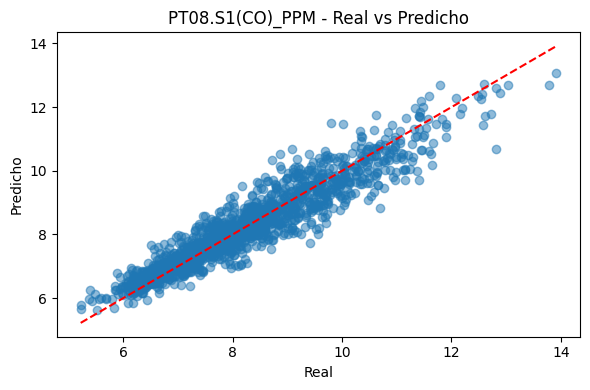

Image saved: images\PT08.S1(CO)_PPM_real_vs_predicho.png


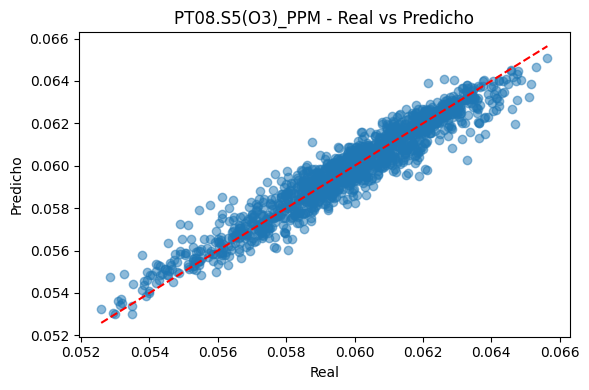

Image saved: images\PT08.S5(O3)_PPM_real_vs_predicho.png


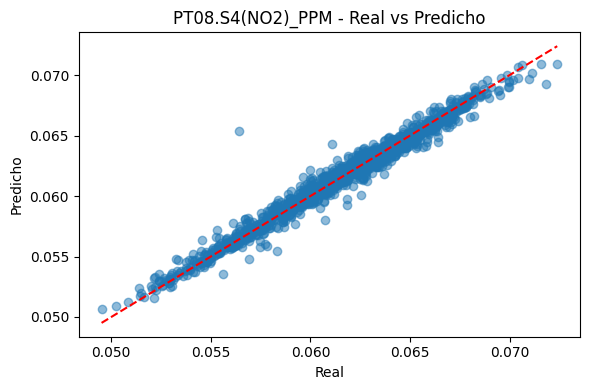

Image saved: images\PT08.S4(NO2)_PPM_real_vs_predicho.png


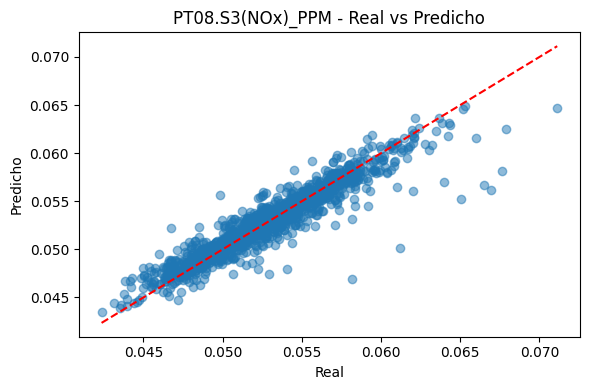

Image saved: images\PT08.S3(NOx)_PPM_real_vs_predicho.png


In [ ]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(targets_ppm[:4]):
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test[col], y_pred[:, i], alpha=0.5)
    plt.plot([y_test[col].min(), y_test[col].max()],
             [y_test[col].min(), y_test[col].max()], 'r--')
    plt.title(f"{col} - Real vs Predicho")
    plt.xlabel("Real")
    plt.ylabel("Predicho")
    plt.tight_layout()

    import os

    # Crear la carpeta images si no existe
    os.makedirs("../images", exist_ok=True)

    filename = os.path.join("images", f"{col}_real_vs_predicho.png")

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Image saved: {filename}")

In [ ]:
X_nuevos = X_test.head(1000).copy()
print("Ejemplo de Nuevos Datos (X_nuevos.head()):")
print(X_nuevos.head())
print("\n")

Ejemplo de Nuevos Datos (X_nuevos.head()):
      CO(GT)  PT08.S2(NMHC)  NOx(GT)  NO2(GT)  C6H6(GT)     T    RH      AH  \
6238     2.8         1124.0    465.0    156.0      14.2  16.8  36.7  0.6944   
9133     1.1          797.0    175.0     80.0       5.7  16.1  69.5  1.2623   
9193     3.7         1063.0    508.0    175.0      12.4  19.6  47.8  1.0781   
9000     1.7          838.0    240.0    128.0       6.6  19.3  41.6  0.9230   
8976     1.9          883.0    266.0    156.0       7.6  18.2  45.9  0.9488   

      HOUR  
6238  16.0  
9133   7.0  
9193  19.0  
9000  18.0  
8976  18.0  




In [ ]:
predicciones_nuevos_datos = model.predict(X_nuevos)

print("Forma de las predicciones:", predicciones_nuevos_datos.shape)

Forma de las predicciones: (1000, 4)


In [ ]:
# Crear un DataFrame con las predicciones
df_predicciones = pd.DataFrame(predicciones_nuevos_datos, columns=targets_ppm)

X_nuevos_reset = X_nuevos.reset_index(drop=True) # Resetear índice para asegurar una unión correcta
df_predicciones_final = pd.concat([X_nuevos_reset, df_predicciones], axis=1)

print("DataFrame Final con Características y Predicciones (df_predicciones_final.head()):")
print(df_predicciones_final.head())
print("\n")

DataFrame Final con Características y Predicciones (df_predicciones_final.head()):
   CO(GT)  PT08.S2(NMHC)  NOx(GT)  NO2(GT)  C6H6(GT)     T    RH      AH  \
0     2.8         1124.0    465.0    156.0      14.2  16.8  36.7  0.6944   
1     1.1          797.0    175.0     80.0       5.7  16.1  69.5  1.2623   
2     3.7         1063.0    508.0    175.0      12.4  19.6  47.8  1.0781   
3     1.7          838.0    240.0    128.0       6.6  19.3  41.6  0.9230   
4     1.9          883.0    266.0    156.0       7.6  18.2  45.9  0.9488   

   HOUR  PT08.S1(CO)_PPM  PT08.S5(O3)_PPM  PT08.S4(NO2)_PPM  PT08.S3(NOx)_PPM  
0  16.0         9.468054         0.061943          0.060885          0.049071  
1   7.0         7.647752         0.059324          0.060722          0.053145  
2  19.0         9.411577         0.061753          0.061767          0.049151  
3  18.0         7.948505         0.058790          0.059774          0.051936  
4  18.0         8.617477         0.059611          0.060083 

#***PARAMETROS IMECA***



In [ ]:
imeca_table_data = {
    'PUNTOS IMECA': [0, 50, 100, 200],
    'CO': [0, 5.5, 11, 22],
    'O3': [0, 0.07, 0.095, 0.204],
    'NO2': [0, 0.105, 0.21, 0.42],
    'NOx': [0, 0.165, 0.33, 0.66]
}

#***FUNCIONES CLASIFICACION***

In [ ]:
imeca_df = pd.DataFrame(imeca_table_data)

imeca_interpolators = {}
for pollutant in ['CO', 'O3', 'NO2', 'NOx']:
    imeca_interpolators[pollutant] = interp1d(
        imeca_df[pollutant],
        imeca_df['PUNTOS IMECA'],
        kind='linear',
        fill_value="extrapolate"
    )

print("Funciones de interpolación IMECA creadas.")

Funciones de interpolación IMECA creadas.


In [ ]:
pred_col_to_imeca_map = {
    'PT08.S1(CO)_PPM': 'CO',
    'PT08.S5(O3)_PPM': 'O3',
    'PT08.S4(NO2)_PPM': 'NO2',
    'PT08.S3(NOx)_PPM': 'NOx'
}


for pred_col, imeca_pollutant in pred_col_to_imeca_map.items():
    imeca_col_name = f'IMECA_{imeca_pollutant}'
    if pred_col in df_predicciones_final.columns:
        df_predicciones_final[imeca_col_name] = df_predicciones_final[pred_col].apply(
            lambda x: imeca_interpolators[imeca_pollutant](x).item()
        )
    else:
        print(f"Advertencia: La columna '{pred_col}' no se encontró en 'df_predicciones_final'. Saltando cálculo IMECA para este contaminante.")

print("\nPuntos IMECA calculados para cada contaminante predicho:")
print(df_predicciones_final[[f'IMECA_{p}' for p in ['CO', 'O3', 'NO2', 'NOx']]].head())


Puntos IMECA calculados para cada contaminante predicho:
    IMECA_CO   IMECA_O3  IMECA_NO2  IMECA_NOx
0  86.073220  44.245140  28.993047  14.869869
1  69.525017  42.374184  28.915278  16.104473
2  85.559790  44.109595  29.412692  14.894353
3  72.259139  41.992921  28.463883  15.738101
4  78.340700  42.578991  28.610829  15.238028


In [ ]:
df_predicciones_final['IMECA_MAX'] = df_predicciones_final[[f'IMECA_{p}' for p in ['CO', 'O3', 'NO2', 'NOx']]].max(axis=1)

imeca_categories = {
    'Buena': (0, 50),
    'Regular': (51, 100),
    'Mala': (101, 150),
    'Muy Mala': (151, 200),
    'Extremadamente Mala': (201, float('inf'))
}

def classify_imeca(imeca_score):
    for category, (lower, upper) in imeca_categories.items():
        if lower <= imeca_score <= upper:
            return category
    return "Desconocida"

df_predicciones_final['Calidad_Aire_IMECA'] = df_predicciones_final['IMECA_MAX'].apply(classify_imeca)

print(df_predicciones_final[['IMECA_MAX', 'Calidad_Aire_IMECA']].head())

   IMECA_MAX Calidad_Aire_IMECA
0  86.073220            Regular
1  69.525017            Regular
2  85.559790            Regular
3  72.259139            Regular
4  78.340700            Regular


#***RESULTADOS CLASIFICACION***

In [ ]:
nombre_archivo_final = '/content/drive/MyDrive/topico/calidad_aire_predicha_imeca.csv'
df_predicciones_final.to_csv(nombre_archivo_final, index=False)
print(df_predicciones_final)
print(f"\nDataFrame actualizado con cálculos IMECA guardado en: {nombre_archivo_final}")

     CO(GT)  PT08.S2(NMHC)  NOx(GT)  NO2(GT)  C6H6(GT)     T    RH      AH  \
0       2.8         1124.0    465.0    156.0      14.2  16.8  36.7  0.6944   
1       1.1          797.0    175.0     80.0       5.7  16.1  69.5  1.2623   
2       3.7         1063.0    508.0    175.0      12.4  19.6  47.8  1.0781   
3       1.7          838.0    240.0    128.0       6.6  19.3  41.6  0.9230   
4       1.9          883.0    266.0    156.0       7.6  18.2  45.9  0.9488   
..      ...            ...      ...      ...       ...   ...   ...     ...   
995     2.0          917.0    231.0     87.0       8.4  17.5  60.7  1.2009   
996     4.0         1399.0    244.0    130.0      23.8  13.3  35.6  0.5416   
997     3.0         1246.0    353.0    138.0      18.2  32.6  34.8  1.6872   
998     1.8         1018.0    130.0    132.0      11.1  40.1  16.1  1.1699   
999     0.8          782.0     75.0     66.0       5.4  23.4  58.6  1.6651   

     HOUR  PT08.S1(CO)_PPM  PT08.S5(O3)_PPM  PT08.S4(NO2)_PPM  